In [ ]:
# import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Read the healthcare dataset

data = pd.read_csv("healthcare.csv")
data.head(3)

,PatientID,Age,Gender,Diagnosis,BloodPressure,Cholesterol,Diabetes,Smoker
0,1001,63,F,Healthy,140,184,No,No
1,1002,76,M,Asthma,115,265,Yes,Yes
2,1003,53,F,Diabetes,118,242,Yes,No


In [ ]:
# Check the information about the dataset

data.info()
data.describe()
data.nunique()
data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PatientID      120 non-null    int64 
 1   Age            120 non-null    int64 
 2   Gender         120 non-null    object
 3   Diagnosis      120 non-null    object
 4   BloodPressure  120 non-null    int64 
 5   Cholesterol    120 non-null    int64 
 6   Diabetes       120 non-null    object
 7   Smoker         120 non-null    object
dtypes: int64(4), object(4)
memory usage: 7.6+ KB


Index(['PatientID', 'Age', 'Gender', 'Diagnosis', 'BloodPressure',
       'Cholesterol', 'Diabetes', 'Smoker'],
      dtype='object')

In [ ]:
# Accessing columns and rows in the dataset

data.iloc[:,1] # OR data["Age"]
data[["Age", "Gender"]] # OR data.iloc[:,1:2]
data.loc[0:5] # Selects only 5 rows by label
data.iloc[0:5, 0:3] # Selects 5 rows for the columns 0 to 3 by index

,PatientID,Age,Gender
0,1001,63,F
1,1002,76,M
2,1003,53,F
3,1004,39,F
4,1005,67,M


In [5]:
# Filtering Data

data[data["Age"]> 50] # To filter out those with age > 50
data[data["Diabetes"]== "Yes"]

,PatientID,Age,Gender,Diagnosis,BloodPressure,Cholesterol,Diabetes,Smoker
1,1002,76,M,Asthma,115,265,Yes,Yes
2,1003,53,F,Diabetes,118,242,Yes,No
7,1008,63,F,Heart Disease,130,252,Yes,Yes
12,1013,35,M,Healthy,130,133,Yes,Yes
21,1022,26,F,Hypertension,131,190,Yes,Yes
26,1027,26,F,Diabetes,148,209,Yes,No
28,1029,45,F,Diabetes,123,120,Yes,No
29,1030,57,F,Diabetes,118,168,Yes,No
33,1034,68,M,Healthy,138,210,Yes,No
37,1038,83,F,Diabetes,126,144,Yes,No


In [ ]:
# Filtering data with multiple conditions

data[(data["Age"]>50) & (data["Smoker"]=="Yes")]

,PatientID,Age,Gender,Diagnosis,BloodPressure,Cholesterol,Diabetes,Smoker
1,1002,76,M,Asthma,115,265,Yes,Yes
7,1008,63,F,Heart Disease,130,252,Yes,Yes
27,1028,84,F,Healthy,144,209,No,Yes
31,1032,82,M,Healthy,160,198,No,Yes
38,1039,66,M,Diabetes,96,152,Yes,Yes
46,1047,79,F,Asthma,117,204,No,Yes
55,1056,63,M,Arthritis,133,230,No,Yes
69,1070,71,F,Arthritis,138,227,No,Yes
70,1071,84,F,Healthy,117,190,No,Yes
79,1080,74,F,Healthy,118,217,Yes,Yes


In [ ]:
# Check for missing values in the dataset

data.isna().sum()
data.dropna()

,PatientID,Age,Gender,Diagnosis,BloodPressure,Cholesterol,Diabetes,Smoker
0,1001,63,F,Healthy,140,184,No,No
1,1002,76,M,Asthma,115,265,Yes,Yes
2,1003,53,F,Diabetes,118,242,Yes,No
3,1004,39,F,Hypertension,119,263,No,No
4,1005,67,M,Obesity,113,226,No,No
...,...,...,...,...,...,...,...,...
115,1116,84,F,Asthma,139,168,No,Yes
116,1117,84,F,Healthy,132,193,No,No
117,1118,69,M,Healthy,125,198,No,No
118,1119,65,F,Arthritis,159,162,No,No


In [8]:
# Handlng missing values

data["Cholesterol"].fillna(data["Cholesterol"].mean(), inplace= True)
data["Cholesterol"].head(4)

0    184
1    265
2    242
3    263
Name: Cholesterol, dtype: int64

In [9]:
# Renaming columns

data.rename(columns = {"BloodPressure": "BP"}, inplace= True)
data.columns

Index(['PatientID', 'Age', 'Gender', 'Diagnosis', 'BP', 'Cholesterol',
       'Diabetes', 'Smoker'],
      dtype='object')

In [ ]:
# Creating New Columns

data["Weight"] = data["PatientID"] ## This is just a placeholder for the weight column, you can replace it with actual weight data if available.
data["Height"] = (data["PatientID"])/10
data["BMI"] = data["Weight"]/((data["Height"])**2)
data["RiskFlag"] = data["BP"]>140
data.head(4)

,PatientID,Age,Gender,Diagnosis,BP,Cholesterol,Diabetes,Smoker,Weight,Height,BMI,RiskFlag
0,1001,63,F,Healthy,140,184,No,No,1001,100.1,0.099900,False
1,1002,76,M,Asthma,115,265,Yes,Yes,1002,100.2,0.099800,False
2,1003,53,F,Diabetes,118,242,Yes,No,1003,100.3,0.099701,False
3,1004,39,F,Hypertension,119,263,No,No,1004,100.4,0.099602,False


In [11]:
# Changing the data types of a column

data["PatientID"] = data["PatientID"].astype(str) # converting it to string
data["PatientID"] = data["PatientID"].astype(int) # Converting it back to integer
data["PatientID"].dtype

dtype('int32')

In [12]:
# Sorting Data sets

data["PatientID"].sort_values() #sorting a particular column
data.sort_values(by = "Age", ascending= True).head(3)

,PatientID,Age,Gender,Diagnosis,BP,Cholesterol,Diabetes,Smoker,Weight,Height,BMI,RiskFlag
82,1083,26,M,Diabetes,136,271,Yes,No,1083,108.3,0.092336,False
66,1067,26,M,Diabetes,118,234,Yes,No,1067,106.7,0.093721,False
26,1027,26,F,Diabetes,148,209,Yes,No,1027,102.7,0.097371,True


In [13]:
# Summarizing Data

data["BP"].mean()
data["Smoker"].value_counts()
data["Diagnosis"].value_counts()

Diagnosis
Healthy          36
Hypertension     21
Obesity          14
Asthma           13
Diabetes         13
Arthritis        12
Heart Disease    11
Name: count, dtype: int64

In [ ]:
# Check the column names in the dataset
data.columns

Index(['PatientID', 'Age', 'Gender', 'Diagnosis', 'BP', 'Cholesterol',
       'Diabetes', 'Smoker', 'Weight', 'Height', 'BMI', 'RiskFlag'],
      dtype='object')

In [15]:
# Grouping Data

data.groupby("Gender")["Cholesterol"].mean()
data.groupby(["Diagnosis", "Gender"])["BP"].var()


Diagnosis      Gender
Arthritis      F         702.266667
               M         249.366667
Asthma         F         203.666667
               M         292.277778
Diabetes       F         114.619048
               M         460.966667
Healthy        F         202.150198
               M         263.897436
Heart Disease  F          94.476190
               M         421.666667
Hypertension   F         261.454545
               M         200.527778
Obesity        F         110.333333
               M         200.290909
Name: BP, dtype: float64

In [16]:
# Building Pivot Tables

pd.pivot_table(data, values= "BP",
               index= "Diagnosis", columns= "Gender",
               aggfunc= "mean")

Gender,F,M
Diagnosis,,
Arthritis,127.333333,130.833333
Asthma,134.500000,126.555556
Diabetes,125.571429,123.833333
Healthy,124.826087,128.307692
Heart Disease,136.142857,138.500000
Hypertension,144.000000,144.444444
Obesity,124.333333,129.090909


In [ ]:
# Create a pivot table

pd.pivot_table(data, index= "Diagnosis", 
               values = "Age", 
               columns= "Smoker")

Smoker,No,Yes
Diagnosis,,
Arthritis,48.666667,61.0
Asthma,53.750000,74.0
Diabetes,49.909091,46.5
Healthy,59.730769,61.8
Heart Disease,59.000000,45.5
Hypertension,51.125000,55.2
Obesity,58.818182,35.0


In [22]:
# Concatenation

df_all = pd.concat([data["Age"], data["PatientID"]])
df_all

0        63
1        76
2        53
3        39
4        67
       ... 
115    1116
116    1117
117    1118
118    1119
119    1120
Length: 240, dtype: int64

In [ ]:
# Create patient demographics with PatientID

patient_demographics = pd.DataFrame({
    'PatientID': [1001, 1002, 1003, 1004, 1005],  # Added PatientID
    'Age': [35, 42, 60, 28, 51],
    'Sex': ['F', 'M', 'F', 'M', 'F']
})

# Create lab results dataset
lab_results = pd.DataFrame({
    'PatientID': [1001, 1001, 1002, 1003, 1004, 1005],
    'TestDate': ['2026-01-15', '2026-02-01', '2026-01-20', '2026-01-18', '2026-01-22', '2026-02-10'],
    'TestName': ['Hemoglobin', 'WBC', 'Hemoglobin', 'Glucose', 'Glucose', 'Hemoglobin'],
    'Result': [12.5, 7.2, 11.8, 180, 95, 13.1],
    'Unit': ['g/dL', 'K/µL', 'g/dL', 'mg/dL', 'mg/dL', 'g/dL']
})

# Merge patient demographics with lab results
df_merged = pd.merge(patient_demographics, lab_results, on="PatientID", how="inner")
print(df_merged)

   PatientID  Age Sex    TestDate    TestName  Result   Unit
0       1001   35   F  2026-01-15  Hemoglobin    12.5   g/dL
1       1001   35   F  2026-02-01         WBC     7.2   K/µL
2       1002   42   M  2026-01-20  Hemoglobin    11.8   g/dL
3       1003   60   F  2026-01-18     Glucose   180.0  mg/dL
4       1004   28   M  2026-01-22     Glucose    95.0  mg/dL
5       1005   51   F  2026-02-10  Hemoglobin    13.1   g/dL


In [38]:
# 1. Inner join - only patients with lab results
df_inner = pd.merge(patient_demographics, lab_results, on="PatientID", how="inner")
print(f"Inner join: {len(df_inner)} rows")

# 2. Left join - all patients, lab results where available
df_left = pd.merge(patient_demographics, lab_results, on="PatientID", how="left")
print(f"Left join: {len(df_left)} rows")

# 3. Right join - all lab results, patient info where available
df_right = pd.merge(patient_demographics, lab_results, on="PatientID", how="right")
print(f"Right join: {len(df_right)} rows")

# 4. Outer join - all patients and all lab results
df_outer = pd.merge(patient_demographics, lab_results, on="PatientID", how="outer")
print(f"Outer join: {len(df_outer)} rows")

Inner join: 6 rows
Left join: 6 rows
Right join: 6 rows
Outer join: 6 rows


In [23]:
# Applying functions

data["AgeGroup"] = data["Age"].apply(lambda x: "Senior" if x>60 else "Adult")
data.groupby(["AgeGroup", "Gender"])["Age"].count()

AgeGroup  Gender
Adult     F         33
          M         35
Senior    F         29
          M         23
Name: Age, dtype: int64

In [ ]:
# Accessing a specific column
data["BP"].head(3)

0    140
1    115
2    118
Name: BP, dtype: int64

In [ ]:
# Categorizing Blood Pressure Levels

conditions = [
    data["BP"] > 140,  # Hypertension
    (data["BP"] >= 120) & (data["BP"] <= 140),  # Elevated
    data["BP"] < 120   # Normal
]
choices = ["High BP (Hypertension)", "Elevated BP", "Normal BP"]

data["BloodPressure_Category"] = np.select(conditions, choices)
data["BloodPressure_Category"].value_counts()

BloodPressure_Category
Elevated BP               55
High BP (Hypertension)    34
Normal BP                 31
Name: count, dtype: int64

In [ ]:
# find the average blood pressure by age group
# and gender:

data.groupby(["Age", "Gender"])["BP"].mean().head(4)

Age  Gender
26   F         139.5
     M         127.0
27   F         118.0
     M         141.0
Name: BP, dtype: float64

In [ ]:
# Saving Datasets

data.to_csv("cleaned_healthcare.csv", index = False)
data.to_excel("cleaned_healthcare.csv", index = False)

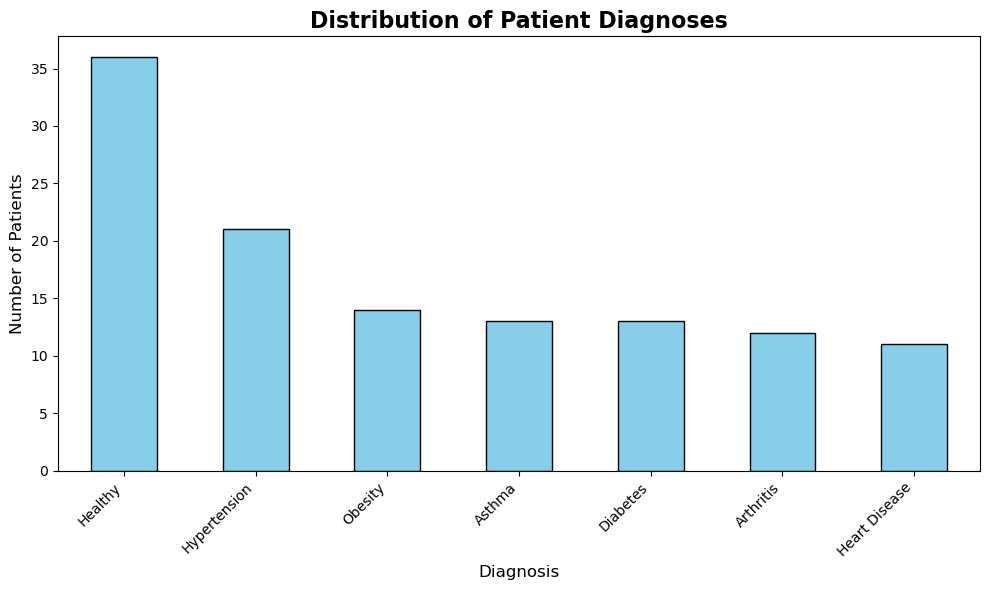

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot of diagnoses
# Shows which health conditions are most prevalent in the dataset.

plt.figure(figsize=(10, 6))
diagnosis_counts = data['Diagnosis'].value_counts()
diagnosis_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Patient Diagnoses', fontsize=16, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

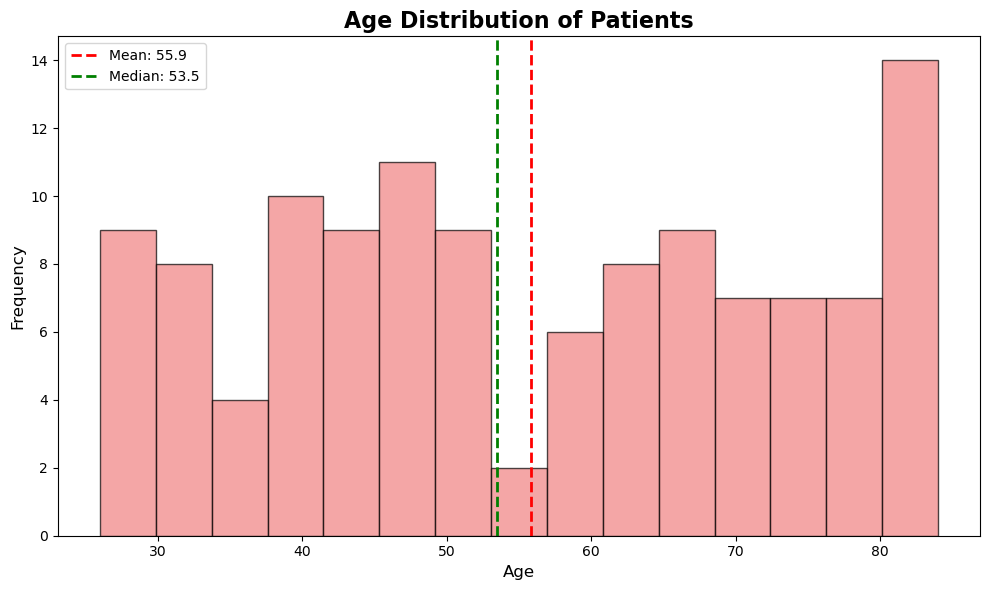

In [ ]:
# Understand the age demographics - is it an elderly population or mixed?

plt.figure(figsize=(10, 6))
plt.hist(data['Age'], bins=15, color='lightcoral', edgecolor='black', alpha=0.7)
plt.title('Age Distribution of Patients', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(data['Age'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {data["Age"].mean():.1f}')
plt.axvline(data['Age'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {data["Age"].median():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

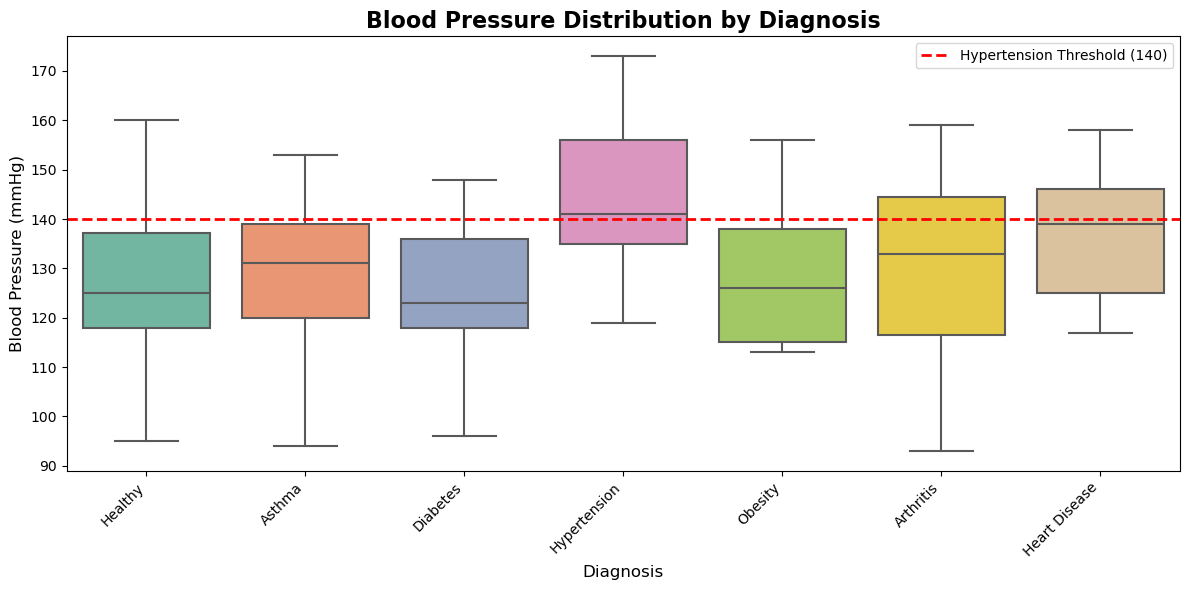

In [ ]:
# See which diagnoses have higher blood pressure. Hypertension and Heart Disease patients should show elevated BP.
# Blood pressure is a critical indicator of cardiovascular health, and this visualization helps 
# identify which diagnoses are associated with higher blood pressure levels.

plt.figure(figsize=(12, 6))
sns.boxplot(x='Diagnosis', y='BP', data=data, palette='Set2')
plt.title('Blood Pressure Distribution by Diagnosis', fontsize=16, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Blood Pressure (mmHg)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(y=140, color='red', linestyle='--', linewidth=2, label='Hypertension Threshold (140)')
plt.legend()
plt.tight_layout()
plt.show()

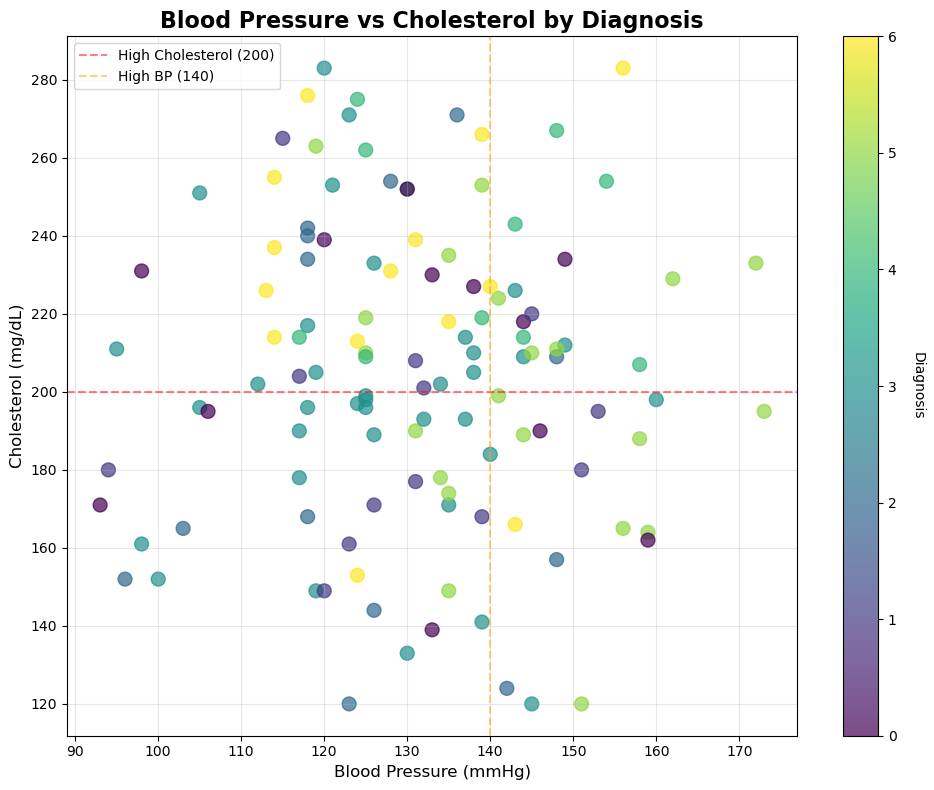

In [ ]:
# Look for clusters of patients with both high BP and high cholesterol.

plt.figure(figsize=(10, 8))
scatter = plt.scatter(data['BP'], data['Cholesterol'], 
                      c=pd.Categorical(data['Diagnosis']).codes, 
                      cmap='viridis', alpha=0.7, s=100)
plt.title('Blood Pressure vs Cholesterol by Diagnosis', fontsize=16, fontweight='bold')
plt.xlabel('Blood Pressure (mmHg)', fontsize=12)
plt.ylabel('Cholesterol (mg/dL)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add colorbar legend
cbar = plt.colorbar(scatter)
cbar.set_label('Diagnosis', rotation=270, labelpad=20)

# Add reference lines
plt.axhline(y=200, color='red', linestyle='--', alpha=0.5, label='High Cholesterol (200)')
plt.axvline(x=140, color='orange', linestyle='--', alpha=0.5, label='High BP (140)')
plt.legend()
plt.tight_layout()
plt.show()

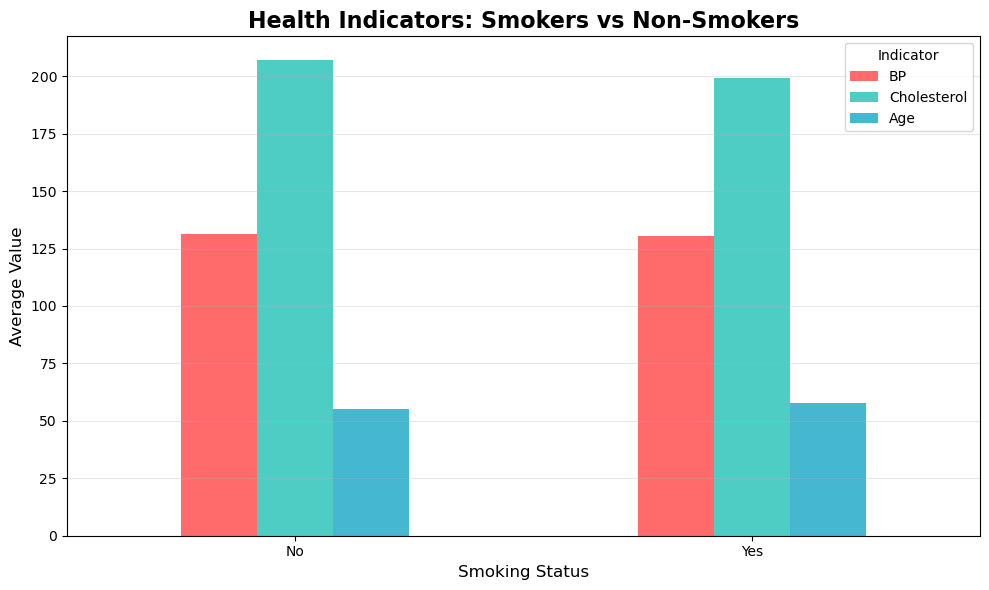

In [ ]:
# Calculate averages by smoking status
# Compare health metrics between smokers and non-smokers. Smokers typically show higher BP and cholesterol.

smoker_avg = data.groupby('Smoker')[['BP', 'Cholesterol', 'Age']].mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
smoker_avg.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Health Indicators: Smokers vs Non-Smokers', fontsize=16, fontweight='bold')
plt.xlabel('Smoking Status', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Indicator', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

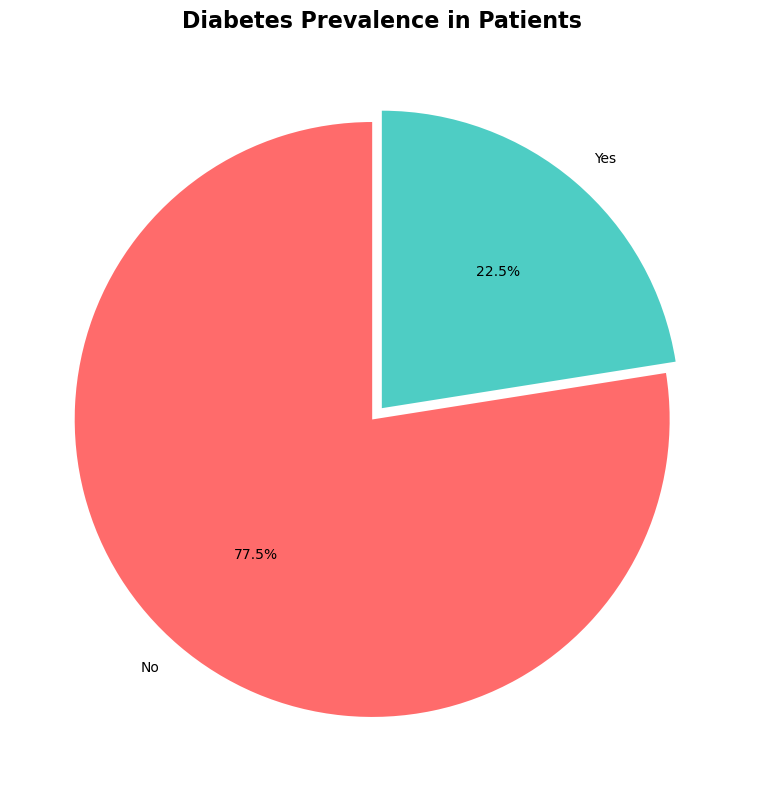

In [ ]:
# visualization of diabetes prevalence in the dataset.

plt.figure(figsize=(8, 8))
diabetes_counts = data['Diabetes'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
plt.pie(diabetes_counts, labels=diabetes_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, explode=(0.05, 0))
plt.title('Diabetes Prevalence in Patients', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

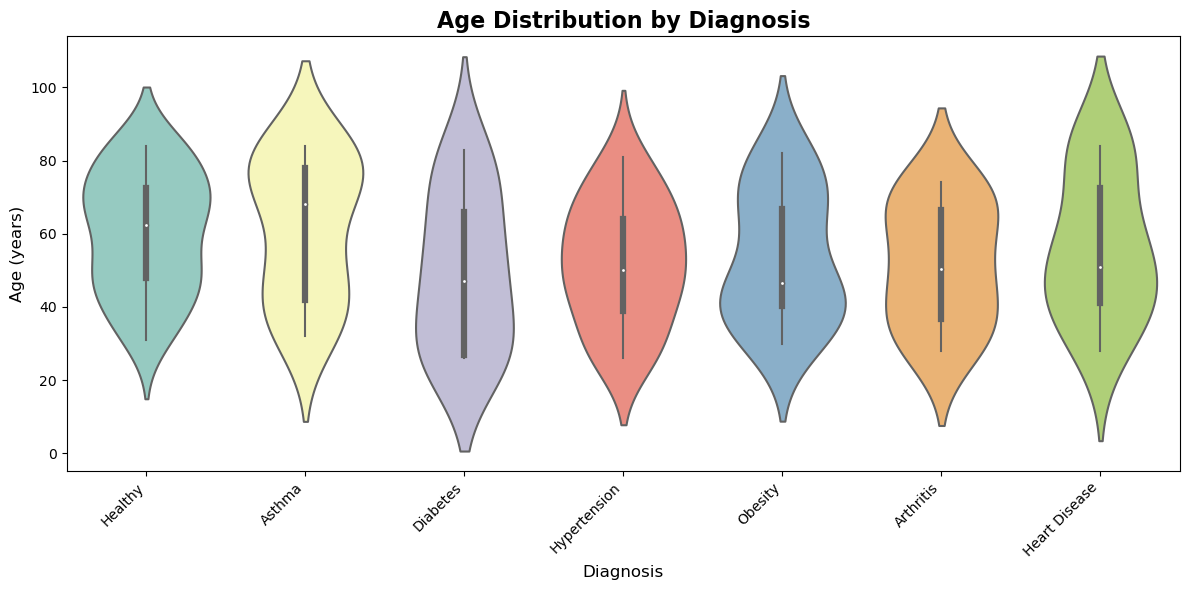

In [ ]:
# Understand age patterns - some conditions are more common in older patients.

plt.figure(figsize=(12, 6))
sns.violinplot(x='Diagnosis', y='Age', data=data, palette='Set3')
plt.title('Age Distribution by Diagnosis', fontsize=16, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

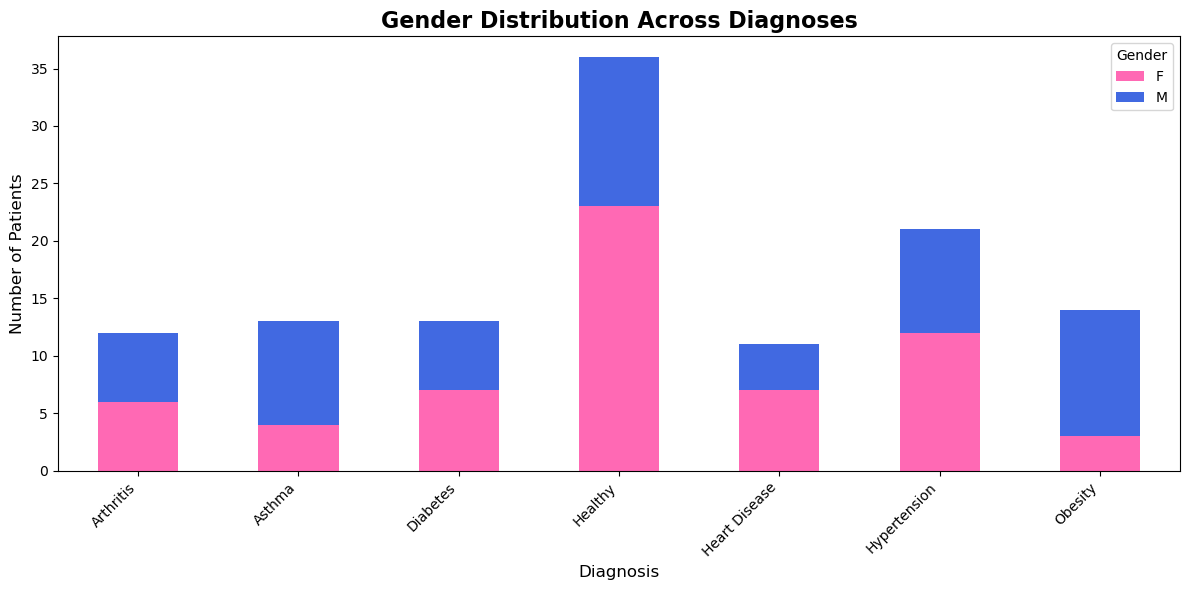

In [ ]:
# Create crosstab
# Identify if certain diagnoses are more common in specific genders.

gender_diagnosis = pd.crosstab(data['Diagnosis'], data['Gender'])

ax = gender_diagnosis.plot(kind='bar', stacked=True, figsize=(12, 6), 
                           color=['#FF69B4', '#4169E1'])
plt.title('Gender Distribution Across Diagnoses', fontsize=16, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender', loc='upper right')
plt.tight_layout()
plt.show()

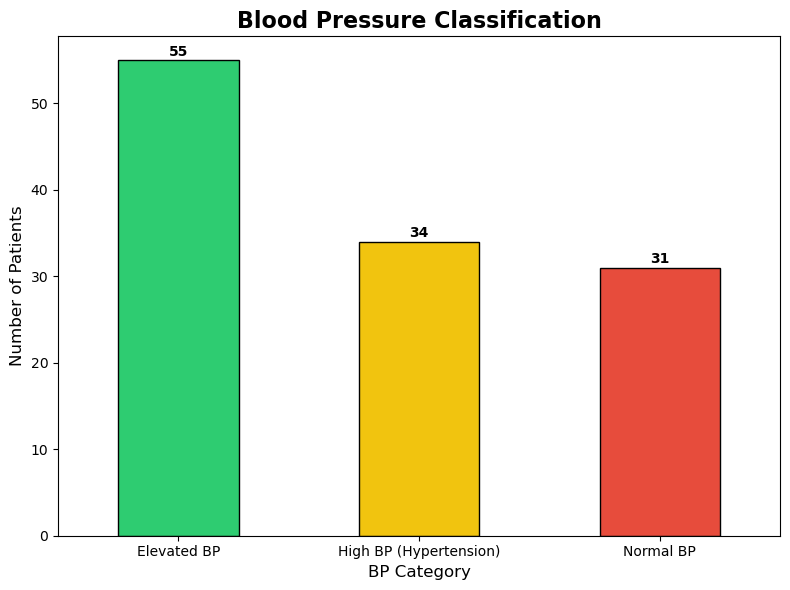

In [ ]:
#  How many patients fall into high-risk BP categories? 

plt.figure(figsize=(8, 6))
bp_categories = data['BloodPressure_Category'].value_counts()
colors = ['#2ECC71', '#F1C40F', '#E74C3C']  # Green, Yellow, Red
bp_categories.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Blood Pressure Classification', fontsize=16, fontweight='bold')
plt.xlabel('BP Category', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(bp_categories):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

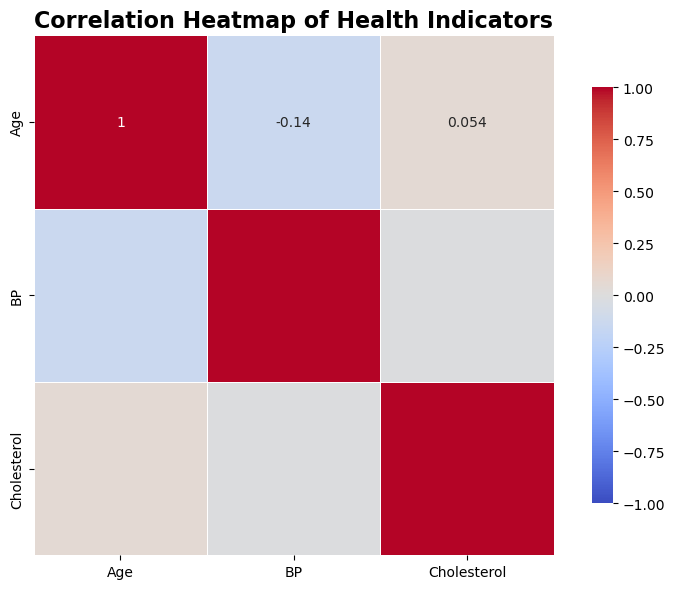

In [ ]:
# Select numerical columns
# Identify relationships between age, BP, and cholesterol.

numerical_cols = ['Age', 'BP', 'Cholesterol']
corr = data[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Health Indicators', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

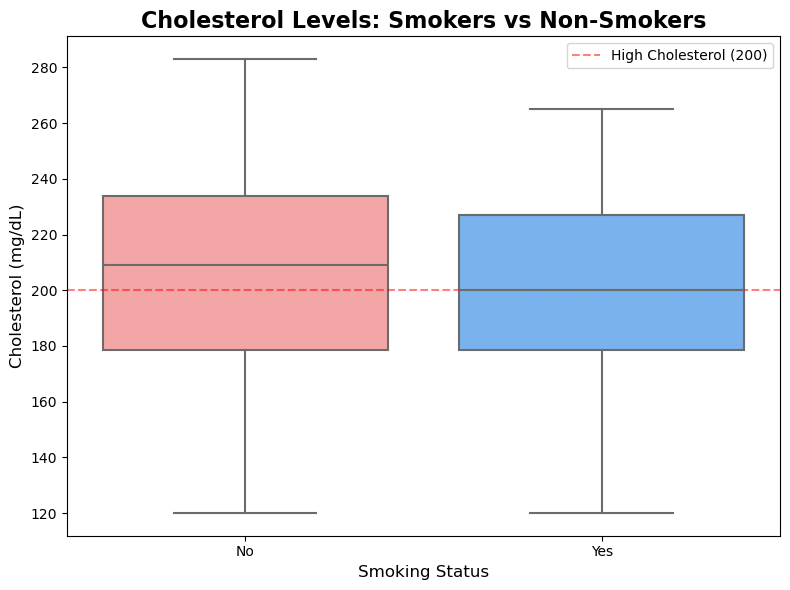

In [58]:
# Compare cholesterol distributions between smokers and non-smokers.

plt.figure(figsize=(8, 6))
sns.boxplot(x='Smoker', y='Cholesterol', data=data, palette=['#FF9999', '#66B2FF'])
plt.title('Cholesterol Levels: Smokers vs Non-Smokers', fontsize=16, fontweight='bold')
plt.xlabel('Smoking Status', fontsize=12)
plt.ylabel('Cholesterol (mg/dL)', fontsize=12)
plt.axhline(y=200, color='red', linestyle='--', alpha=0.5, label='High Cholesterol (200)')
plt.legend()
plt.tight_layout()
plt.show()

c:\Users\3D\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\3D\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\3D\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


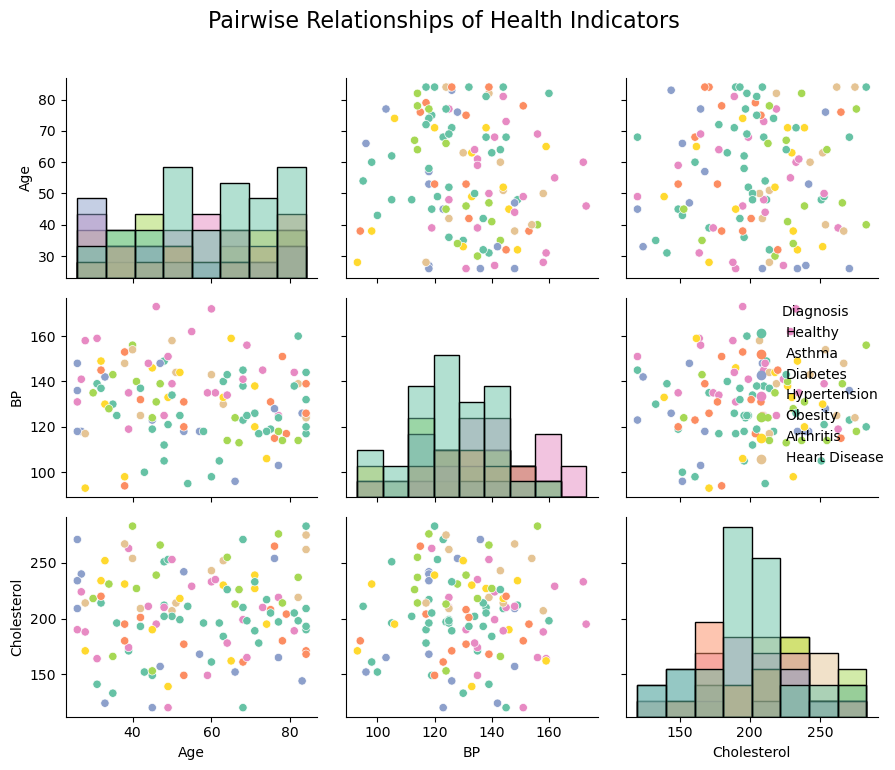

In [ ]:
# Select relevant columns and create pairplot
#  Comprehensive overview of relationships between all numerical variables.


plt.figure(figsize=(10, 6))
sns.regplot(x='Age', y='BP', data=data, scatter_kws={'alpha':0.6}, 
            line_kws={'color':'red'})
plt.title('Blood Pressure vs Age (with Trend Line)', fontsize=16, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Blood Pressure (mmHg)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
Insight: Determine if BP increases with age.

14. Multiple Health Indicators by Diagnosis (Facet Grid)
python
# Create a facet grid
g = sns.FacetGrid(data, col='Diagnosis', col_wrap=4, height=3, sharex=False)
g.map(plt.hist, 'BP', bins=10, alpha=0.7, color='steelblue', edgecolor='black')
g.set_axis_labels('Blood Pressure (mmHg)', 'Frequency')
g.set_titles(col_template='{col_name}')
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Blood Pressure Distribution by Diagnosis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
Insight: See BP distribution patterns for each diagnosis individually.

15. Interactive Dashboard (Bonus - Using Plotly)
python
import plotly.express as px

# Create interactive scatter plot
fig = px.scatter(data, x='Age', y='BP', color='Diagnosis', 
                 size='Cholesterol', hover_data=['PatientID', 'Smoker'],
                 title='Patient Health Dashboard: Age vs Blood Pressure',
                 labels={'BP': 'Blood Pressure (mmHg)', 'Age': 'Age (years)'})
fig.show()
📈 Recommended Analysis Workflow
Create a comprehensive dashboard with these plots:

python
# Complete visualization suite
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Plot 1: Diagnosis distribution
data['Diagnosis'].value_counts().plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Diagnosis Distribution')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Age histogram
axes[0,1].hist(data['Age'], bins=15, color='lightcoral', edgecolor='black')
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age')

# Plot 3: BP by diagnosis
sns.boxplot(x='Diagnosis', y='BP', data=data, ax=axes[0,2])
axes[0,2].set_title('BP by Diagnosis')
axes[0,2].tick_params(axis='x', rotation=45)

# Plot 4: Smoker distribution
data['Smoker'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('Smoker Distribution')

# Plot 5: Cholesterol by smoking
sns.boxplot(x='Smoker', y='Cholesterol', data=data, ax=axes[1,1])
axes[1,1].set_title('Cholesterol: Smokers vs Non-Smokers')

# Plot 6: BP categories
data['BloodPressure_Category'].value_counts().plot(kind='bar', ax=axes[1,2], 
                                                    color=['green','yellow','red'])
axes[1,2].set_title('BP Categories')
axes[1,2].tick_params(axis='x', rotation=0)

# Plot 7: Scatter BP vs Cholesterol
axes[2,0].scatter(data['BP'], data['Cholesterol'], alpha=0.6)
axes[2,0].set_xlabel('BP')
axes[2,0].set_ylabel('Cholesterol')
axes[2,0].set_title('BP vs Cholesterol')

# Plot 8: Gender distribution
data['Gender'].value_counts().plot(kind='bar', ax=axes[2,1], color=['pink','lightblue'])
axes[2,1].set_title('Gender Distribution')

# Plot 9: Diabetes prevalence
data['Diabetes'].value_counts().plot(kind='bar', ax=axes[2,2], color=['lightgreen','salmon'])
axes[2,2].set_title('Diabetes Status')

plt.suptitle('Healthcare Data Analysis Dashboard', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
📊 Summary of Most Important Plots
Plot Type	Variables	Best For
Bar Chart	Diagnosis counts	Understanding data composition
Histogram	Age	Understanding patient demographics
Box Plot	BP by Diagnosis	Comparing distributions across groups
Scatter Plot	BP vs Cholesterol	Finding correlations
Heatmap	Numerical variables	Overall correlation analysis
Pie Chart	Smoking/Diabetes	Quick prevalence overview
Violin Plot	Age by Diagnosis	Distribution shape comparisons
These plots will provide comprehensive insights into your healthcare data and make your GitHub project much more impressive! 🎉


selected_data = data[['Age', 'BP', 'Cholesterol', 'Diagnosis']]
sns.pairplot(selected_data, hue='Diagnosis', height=2.5, 
             diag_kind='hist', palette='Set2')
plt.suptitle('Pairwise Relationships of Health Indicators', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

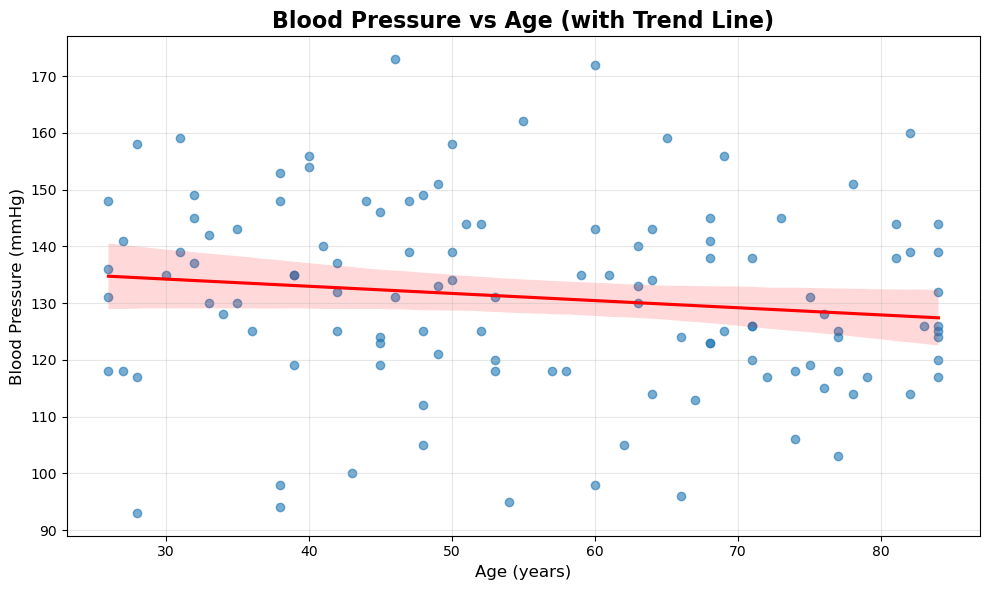

In [ ]:
#  Determine if BP increases with age.

plt.figure(figsize=(10, 6))
sns.regplot(x='Age', y='BP', data=data, scatter_kws={'alpha':0.6}, 
            line_kws={'color':'red'})
plt.title('Blood Pressure vs Age (with Trend Line)', fontsize=16, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Blood Pressure (mmHg)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

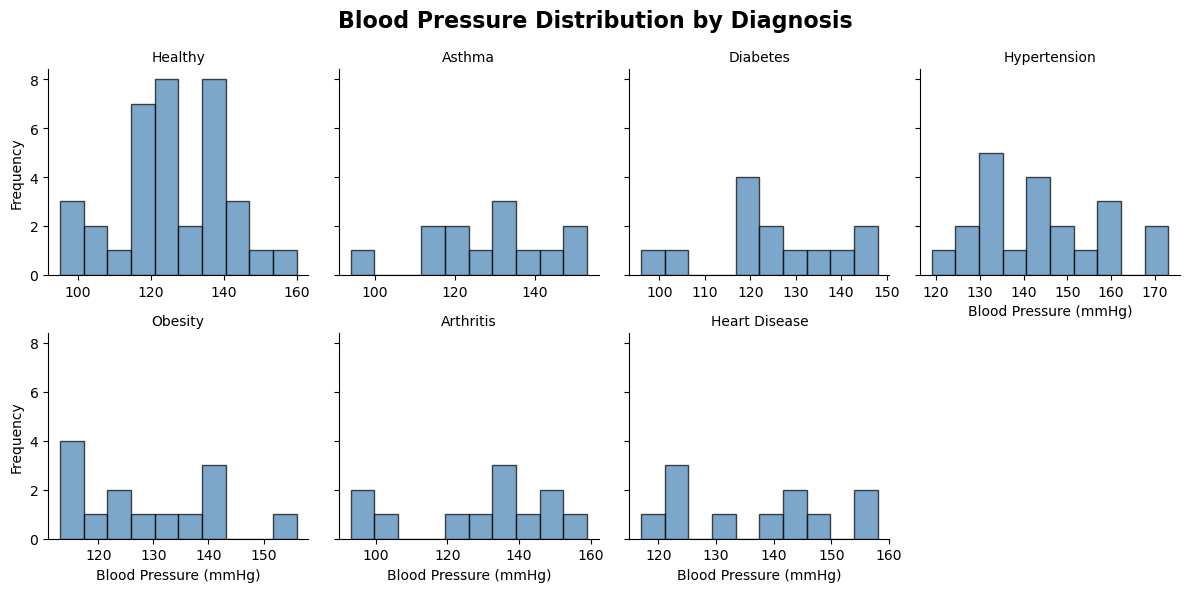

In [53]:
# See BP distribution patterns for each diagnosis individually.
# Create a facet grid

g = sns.FacetGrid(data, col='Diagnosis', col_wrap=4, height=3, sharex=False)
g.map(plt.hist, 'BP', bins=10, alpha=0.7, color='steelblue', edgecolor='black')
g.set_axis_labels('Blood Pressure (mmHg)', 'Frequency')
g.set_titles(col_template='{col_name}')
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Blood Pressure Distribution by Diagnosis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
import plotly.express as px

# Create interactive scatter plot
fig = px.scatter(data, x='Age', y='BP', color='Diagnosis', 
                 size='Cholesterol', hover_data=['PatientID', 'Smoker'],
                 title='Patient Health Dashboard: Age vs Blood Pressure',
                 labels={'BP': 'Blood Pressure (mmHg)', 'Age': 'Age (years)'})
fig.show()

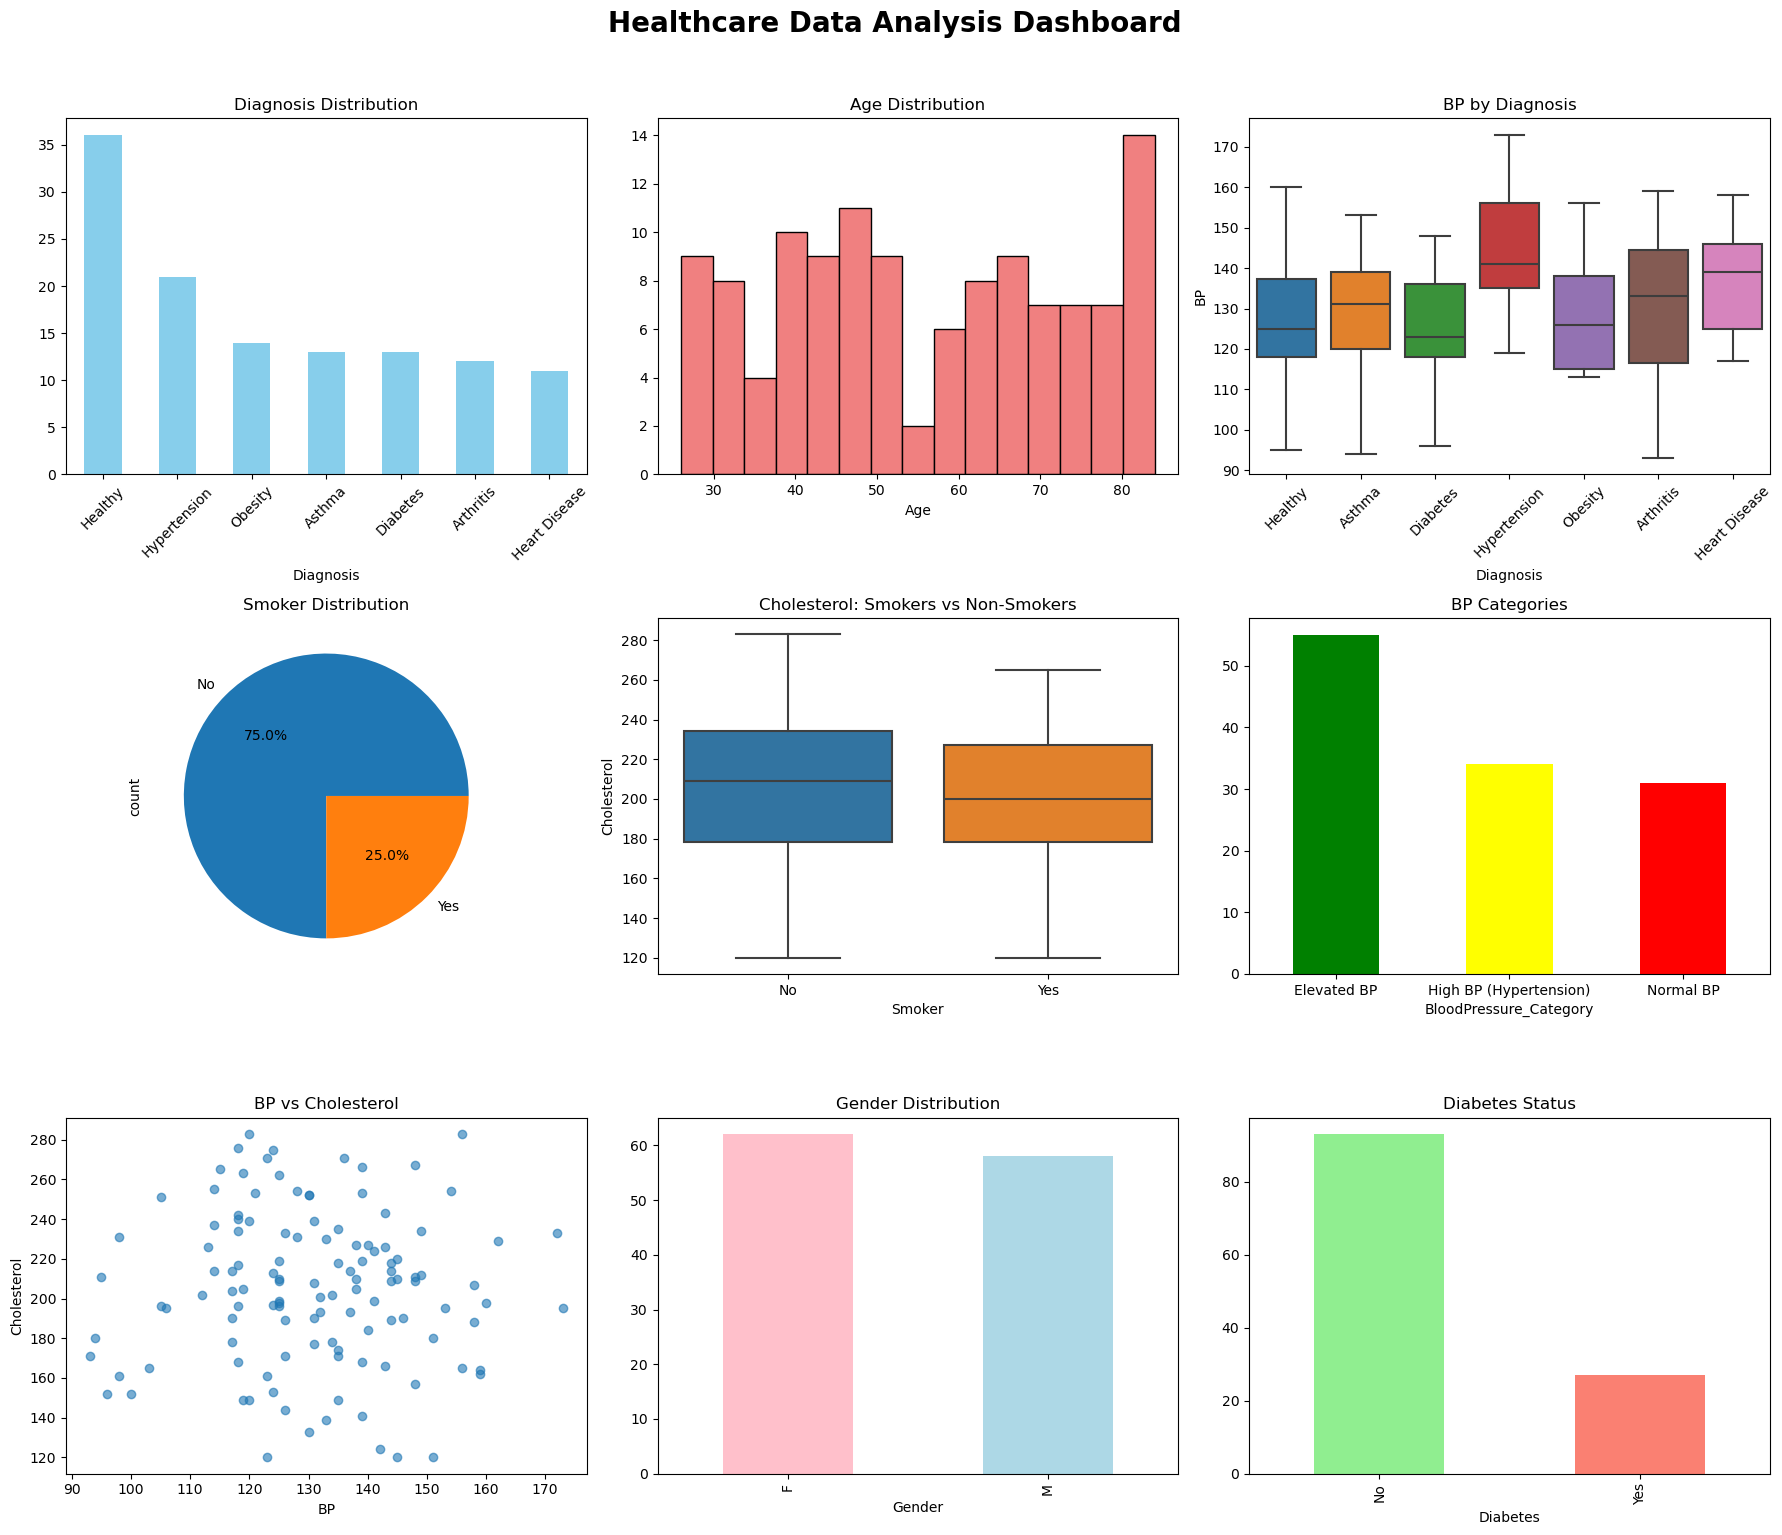

In [56]:
# Complete visualization suite
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Plot 1: Diagnosis distribution
data['Diagnosis'].value_counts().plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Diagnosis Distribution')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Age histogram
axes[0,1].hist(data['Age'], bins=15, color='lightcoral', edgecolor='black')
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age')

# Plot 3: BP by diagnosis
sns.boxplot(x='Diagnosis', y='BP', data=data, ax=axes[0,2])
axes[0,2].set_title('BP by Diagnosis')
axes[0,2].tick_params(axis='x', rotation=45)

# Plot 4: Smoker distribution
data['Smoker'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('Smoker Distribution')

# Plot 5: Cholesterol by smoking
sns.boxplot(x='Smoker', y='Cholesterol', data=data, ax=axes[1,1])
axes[1,1].set_title('Cholesterol: Smokers vs Non-Smokers')

# Plot 6: BP categories
data['BloodPressure_Category'].value_counts().plot(kind='bar', ax=axes[1,2], 
                                                    color=['green','yellow','red'])
axes[1,2].set_title('BP Categories')
axes[1,2].tick_params(axis='x', rotation=0)

# Plot 7: Scatter BP vs Cholesterol
axes[2,0].scatter(data['BP'], data['Cholesterol'], alpha=0.6)
axes[2,0].set_xlabel('BP')
axes[2,0].set_ylabel('Cholesterol')
axes[2,0].set_title('BP vs Cholesterol')

# Plot 8: Gender distribution
data['Gender'].value_counts().plot(kind='bar', ax=axes[2,1], color=['pink','lightblue'])
axes[2,1].set_title('Gender Distribution')

# Plot 9: Diabetes prevalence
data['Diabetes'].value_counts().plot(kind='bar', ax=axes[2,2], color=['lightgreen','salmon'])
axes[2,2].set_title('Diabetes Status')

plt.suptitle('Healthcare Data Analysis Dashboard', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()